# Financial Decision Support System for Loan Approval

### Machine Learning Based Loan Approval Prediction

**Dataset:** Loan Approval Dataset

**Objective:**  
To analyze applicant information, identify meaningful patterns, and develop
machine learning models that can support consistent loan approval decisions.

### Machine Learning Models
1. Decision Tree Classifier
2. K-Nearest Neighbors (KNN)

## Problem Statement

Financial organizations receive loan applications from individuals with
different demographic, employment, and financial characteristics.

The objective of this project is to analyze historical applicant data and
develop a machine learning based decision-support system that predicts
whether a loan application is likely to be approved.

The project also investigates the consequences of different prediction
errors, since approving a high-risk applicant and rejecting a potentially
creditworthy applicant can have different financial consequences.

## Dataset Description

The dataset contains 1,000 loan applicants and 11 variables.

The available information includes:

- Age
- Gender
- Marital status
- Annual income
- Loan amount
- Credit score
- Number of dependents
- Number of existing loans
- Employment status
- Loan approval outcome

The target variable is `loan_approved`:

- 1 → Loan Approved
- 0 → Loan Rejected

`applicant_id` is an identifier and will not be used as a predictive feature.

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("loanapproval.csv")
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 11


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [7]:
df.columns

Index(['applicant_id', 'age', 'gender', 'marital_status', 'annual_income',
       'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='object')

In [8]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 applicant_id
[   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  191  192  193  194  

In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64


### Observation

The dataset contains no missing values. Therefore, no imputation is
required for the current dataset.

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
print("Dataset shape before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape before removing duplicates: (1000, 11)
Dataset shape after removing duplicates: (1000, 11)


# Observation
The dataset contains no duplicate values since the shape of the dataframe remains the same before and after removing duplicates.



In [12]:
print(df.dtypes)

applicant_id             int64
age                      int64
gender                  object
marital_status          object
annual_income            int64
loan_amount              int64
credit_score             int64
num_dependents           int64
existing_loans_count     int64
employment_status       object
loan_approved            int64
dtype: object


In [13]:
df.nunique()

,0
applicant_id,1000
age,44
gender,2
marital_status,3
annual_income,996
loan_amount,990
credit_score,452
num_dependents,5
existing_loans_count,5
employment_status,3


In [14]:
df.describe()

,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [15]:
print("Age outside expected range:")
print(df[(df["age"] < 18) | (df["age"] > 100)])

print("\nInvalid credit scores:")
print(df[(df["credit_score"] < 300) | (df["credit_score"] > 850)])

print("\nNegative income values:")
print(df[df["annual_income"] < 0])

print("\nNegative loan amounts:")
print(df[df["loan_amount"] < 0])

Age outside expected range:
Empty DataFrame
Columns: [applicant_id, age, gender, marital_status, annual_income, loan_amount, credit_score, num_dependents, existing_loans_count, employment_status, loan_approved]
Index: []

Invalid credit scores:
Empty DataFrame
Columns: [applicant_id, age, gender, marital_status, annual_income, loan_amount, credit_score, num_dependents, existing_loans_count, employment_status, loan_approved]
Index: []

Negative income values:
Empty DataFrame
Columns: [applicant_id, age, gender, marital_status, annual_income, loan_amount, credit_score, num_dependents, existing_loans_count, employment_status, loan_approved]
Index: []

Negative loan amounts:
Empty DataFrame
Columns: [applicant_id, age, gender, marital_status, annual_income, loan_amount, credit_score, num_dependents, existing_loans_count, employment_status, loan_approved]
Index: []


### Data Quality Observation

The dataset was checked for invalid values in important financial and
demographic variables. The observed values fall within reasonable ranges,
and no negative income or loan amounts were found.

Therefore, no records required removal based on invalid numerical values.

In [16]:
numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "num_dependents",
    "existing_loans_count"
]

df[numeric_columns].mean()

,0
age,42.515
annual_income,81972.972
loan_amount,27244.866
credit_score,576.125
num_dependents,1.977
existing_loans_count,2.042


In [17]:
df[numeric_columns].median()

,0
age,43.0
annual_income,82050.0
loan_amount,27041.5
credit_score,573.5
num_dependents,2.0
existing_loans_count,2.0


In [18]:
df[numeric_columns].mode().iloc[0]

,0
age,46.0
annual_income,69416.0
loan_amount,6932.0
credit_score,536.0
num_dependents,0.0
existing_loans_count,1.0


In [19]:
df[numeric_columns].var()

,0
age,1.590388e+02
annual_income,1.409796e+09
loan_amount,1.644230e+08
credit_score,2.431151e+04
num_dependents,2.012483e+00
existing_loans_count,1.998234e+00


In [20]:
df[numeric_columns].std()

,0
age,12.611059
annual_income,37547.255418
loan_amount,12822.752877
credit_score,155.921483
num_dependents,1.418620
existing_loans_count,1.413589


### Statistical Observation

The average applicant age is approximately 42.5 years, while the average
annual income is approximately 81,973 and the average loan amount is
approximately 27,245.

The mean credit score is approximately 576, with a standard deviation of
about 156, indicating substantial variation in applicants' credit scores.

The mean and median values are relatively close for most variables,
suggesting that extreme skewness is not dominant in these variables.

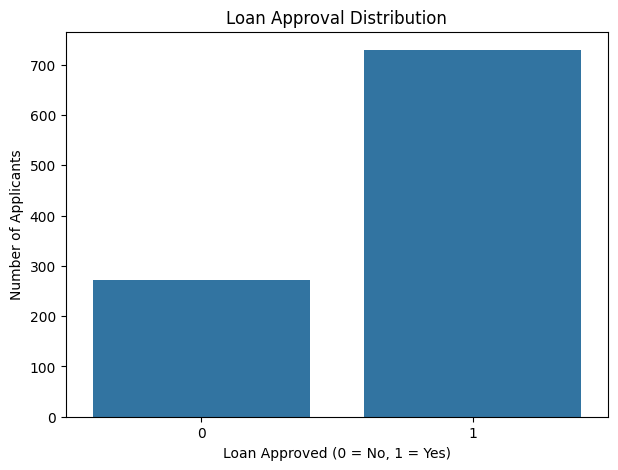

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="loan_approved")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Number of Applicants")

plt.show()

In [22]:
approval_percentage = (
    df["loan_approved"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(approval_percentage)

loan_approved
0    27.1
1    72.9
Name: proportion, dtype: float64


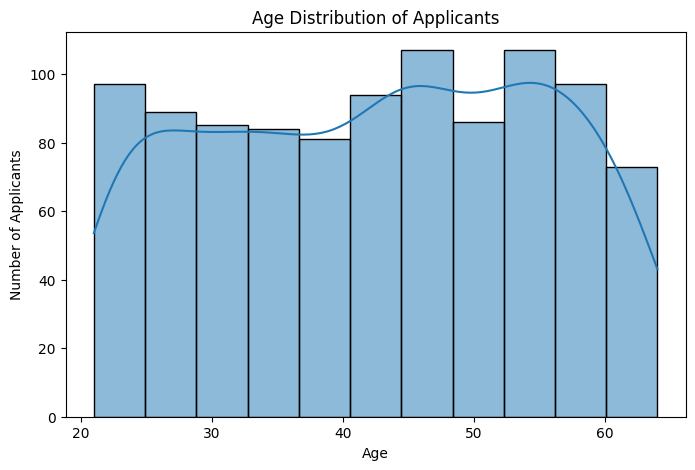

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    kde=True
)

plt.title("Age Distribution of Applicants")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.show()

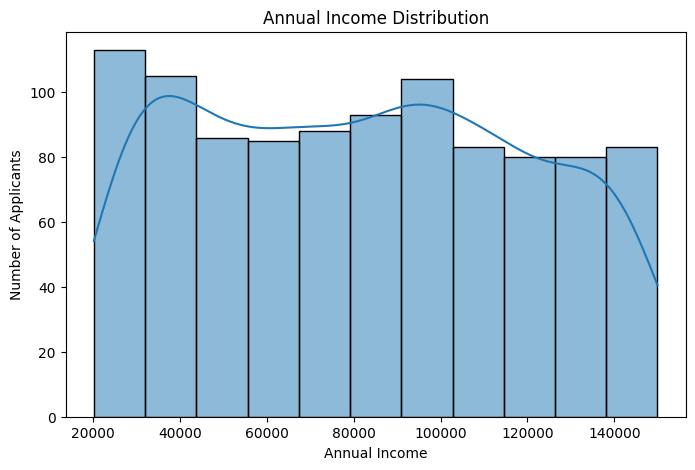

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="annual_income",
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")

plt.show()

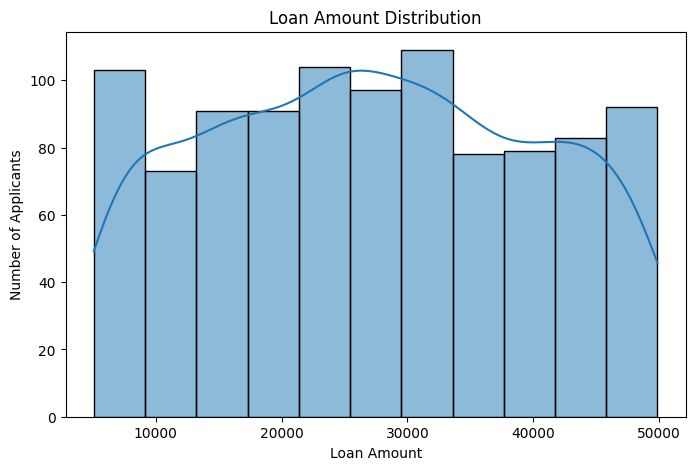

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="loan_amount",
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.show()

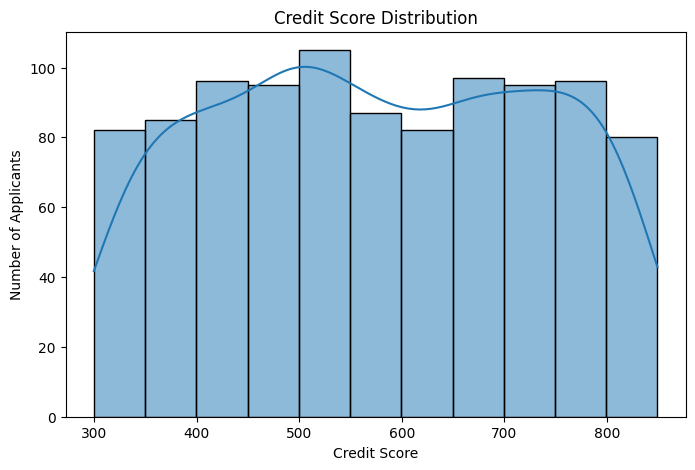

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="credit_score",
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")

plt.show()

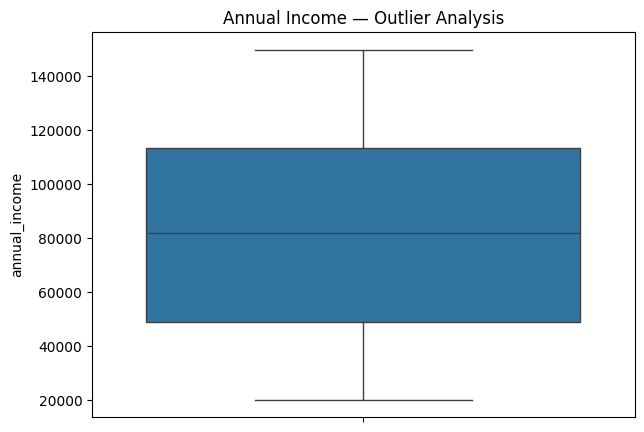

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    y="annual_income"
)

plt.title("Annual Income — Outlier Analysis")

plt.show()

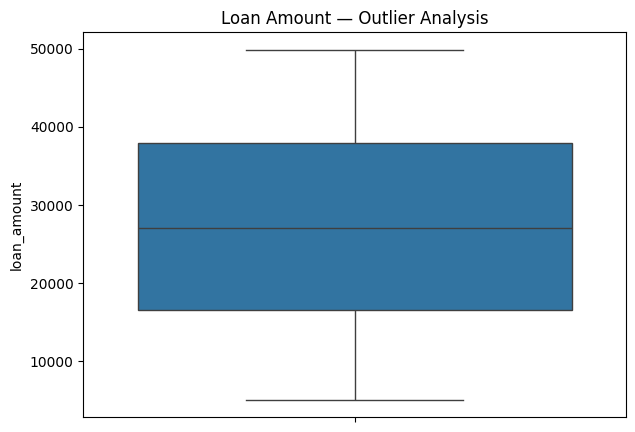

In [28]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    y="loan_amount"
)

plt.title("Loan Amount — Outlier Analysis")

plt.show()

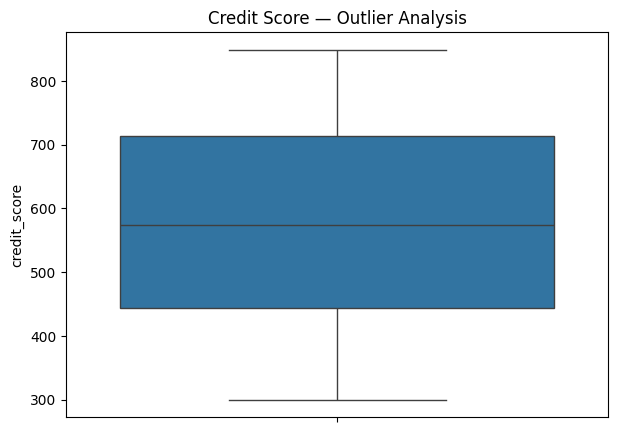

In [29]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    y="credit_score"
)

plt.title("Credit Score — Outlier Analysis")

plt.show()

## Outlier Analysis

Boxplots were used to identify potential outliers in annual income,
loan amount and credit score.

Potential outliers are not automatically removed because unusually high
or low financial values may represent genuine applicants rather than
data-entry errors.

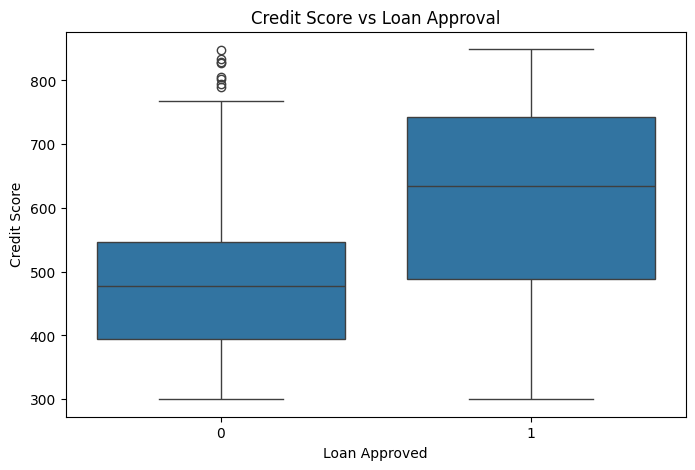

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_approved",
    y="credit_score"
)

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")

plt.show()

### Observation: Credit Score and Loan Approval

Applicants who received loan approval generally have higher credit scores
than applicants whose loans were rejected.

The analysis by credit-score category also shows a clear increase in approval
rate as credit score improves:

- Low: approximately 57.5%
- Fair: approximately 67.3%
- Good: approximately 91.2%
- Excellent: approximately 93.6%

This suggests that credit score is an important variable associated with
loan approval.

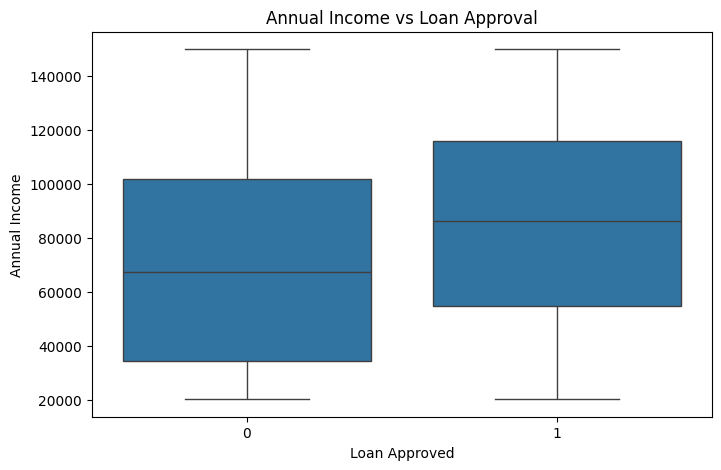

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_approved",
    y="annual_income"
)

plt.title("Annual Income vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Annual Income")

plt.show()

### Observation: Annual Income

The average annual income of approved applicants is higher than that of
rejected applicants.

Approved applicants have an average income of approximately 86,010,
compared with approximately 71,112 for rejected applicants.

This suggests that income may have a positive relationship with the
historical loan approval outcome.

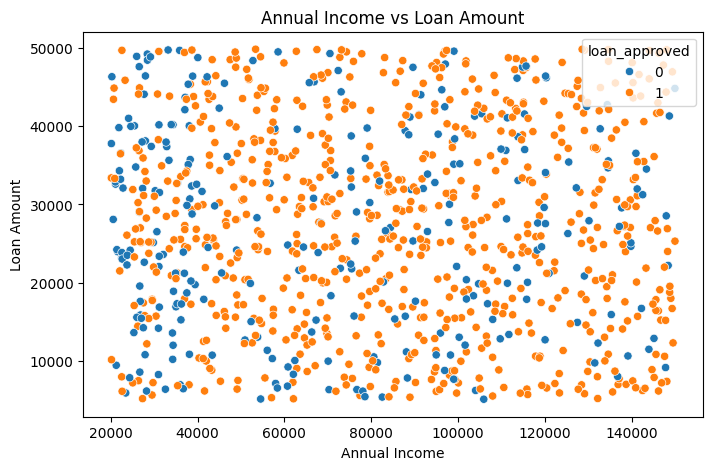

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="annual_income",
    y="loan_amount",
    hue="loan_approved"

)

plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")

plt.show()

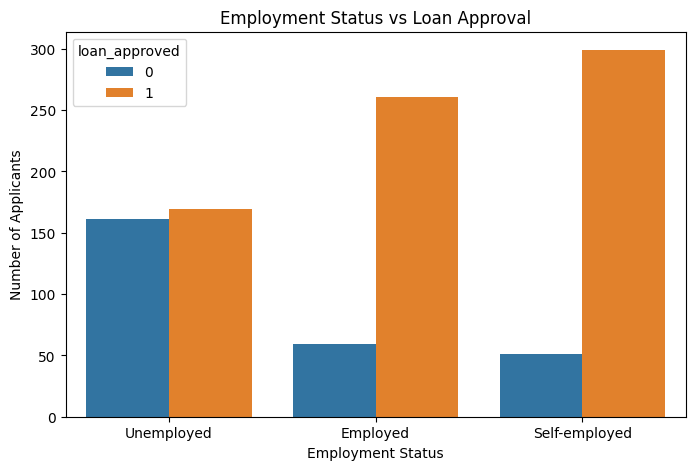

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="employment_status",
    hue="loan_approved"
)

plt.title("Employment Status vs Loan Approval")
plt.xlabel("Employment Status")
plt.ylabel("Number of Applicants")

plt.show()

### Observation: Employment Status

Loan approval rates differ substantially across employment categories.

The approval rates are approximately:

- Employed: 81.6%
- Self-employed: 85.4%
- Unemployed: 51.2%

Applicants classified as unemployed have a substantially lower approval
rate than employed and self-employed applicants.

This suggests that employment status may be an important factor in the
historical approval decisions.

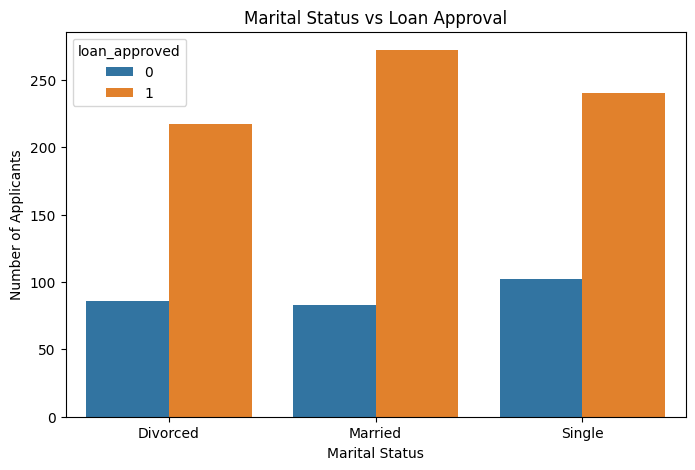

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="marital_status",
    hue="loan_approved"
)

plt.title("Marital Status vs Loan Approval")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applicants")

plt.show()

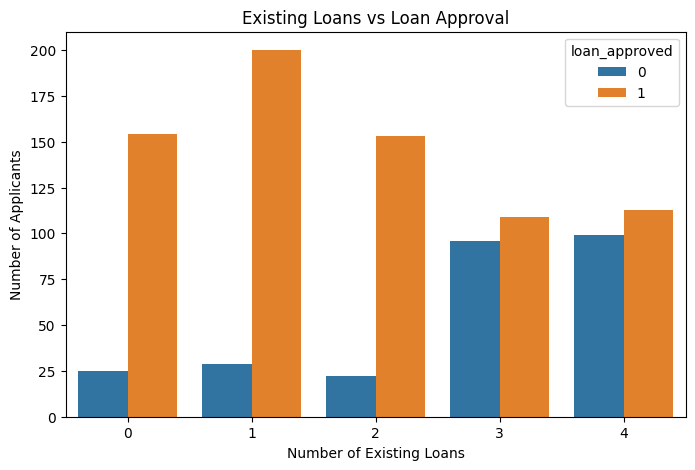

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="existing_loans_count",
    hue="loan_approved"
)

plt.title("Existing Loans vs Loan Approval")
plt.xlabel("Number of Existing Loans")
plt.ylabel("Number of Applicants")

plt.show()

### Observation: Existing Loans

Applicants with more existing loans generally show lower loan approval
rates.

This may indicate that existing financial obligations are associated with
lower historical approval rates.

In [36]:
approval_by_employment = df.groupby(
    "employment_status"
)["loan_approved"].mean() * 100

print("Loan approval percentage by employment status:")
print(approval_by_employment)

Loan approval percentage by employment status:
employment_status
Employed         81.562500
Self-employed    85.428571
Unemployed       51.212121
Name: loan_approved, dtype: float64


In [37]:
df["credit_category"] = pd.cut(
    df["credit_score"],
    bins=[0, 500, 650, 750, 900],
    labels=[
        "Low",
        "Fair",
        "Good",
        "Excellent"
    ]
)

credit_approval = df.groupby(
    "credit_category",
    observed=False
)["loan_approved"].mean() * 100

print(credit_approval)

credit_category
Low          57.458564
Fair         67.279412
Good         91.191710
Excellent    93.641618
Name: loan_approved, dtype: float64


In [38]:
correlation_matrix = df[
    numeric_columns + ["loan_approved"]
].corr()

correlation_matrix

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
age,1.000000,0.002591,0.000235,0.052769,-0.031510,0.063977,0.020984
annual_income,0.002591,1.000000,-0.024862,0.016921,-0.016445,-0.010745,0.176453
loan_amount,0.000235,-0.024862,1.000000,0.044939,0.037140,-0.012043,0.015355
credit_score,0.052769,0.016921,0.044939,1.000000,-0.067063,0.017398,0.351167
num_dependents,-0.031510,-0.016445,0.037140,-0.067063,1.000000,0.046405,-0.365317
existing_loans_count,0.063977,-0.010745,-0.012043,0.017398,0.046405,1.000000,-0.324236
loan_approved,0.020984,0.176453,0.015355,0.351167,-0.365317,-0.324236,1.000000


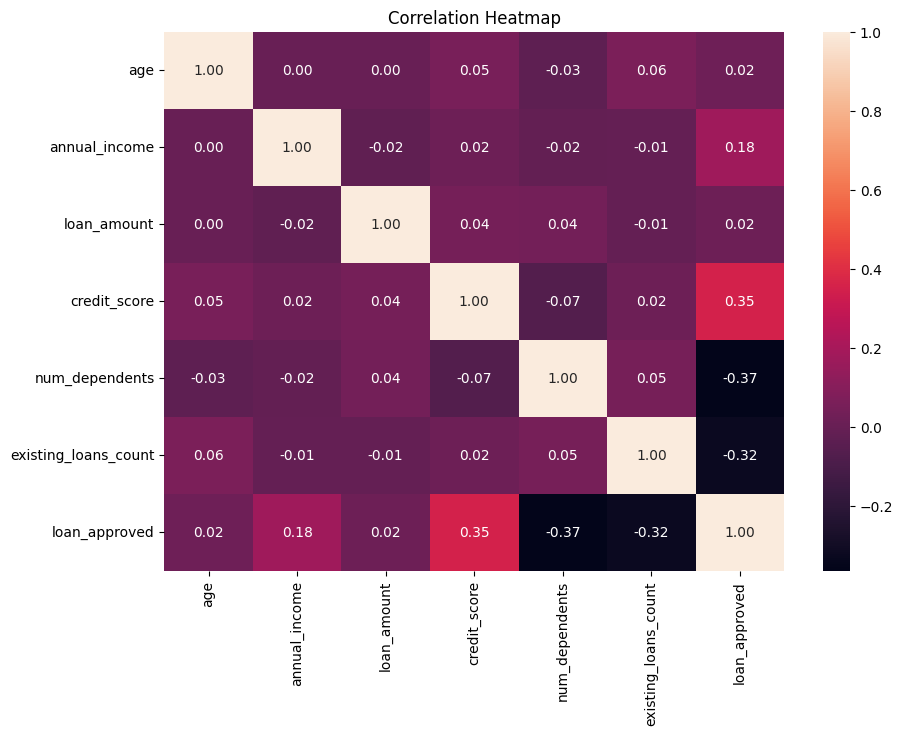

In [39]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis

Correlation analysis was performed to identify relationships between
the numerical variables and the loan approval outcome.

The correlation values help identify variables that may have a stronger
linear association with loan approval. However, correlation does not
necessarily imply causation.

In [40]:
df["loan_income_ratio"] = (
    df["loan_amount"] / df["annual_income"]
)

df["loan_income_ratio"].describe()

,loan_income_ratio
count,1000.000000
mean,0.445871
std,0.369281
min,0.039148
25%,0.194760
50%,0.337716
75%,0.572502
max,2.285080


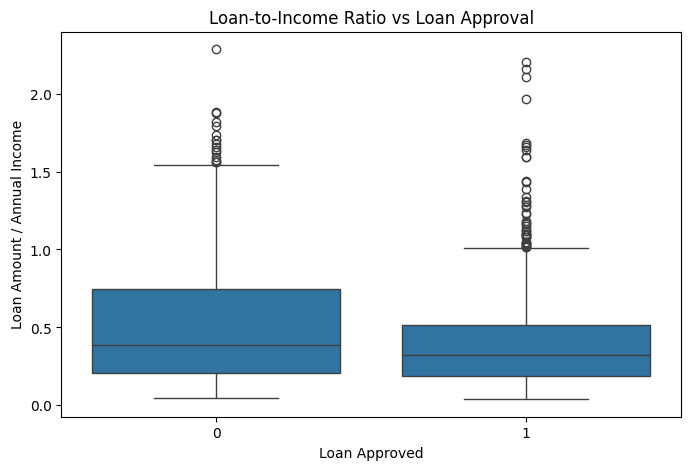

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="loan_approved",
    y="loan_income_ratio"
)

plt.title("Loan-to-Income Ratio vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Loan Amount / Annual Income")

plt.show()

In [42]:
X = df.drop(
    columns=["loan_approved", "applicant_id", "credit_category"]
)

y = df["loan_approved"]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Feature columns:
['age', 'gender', 'marital_status', 'annual_income', 'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count', 'employment_status', 'loan_income_ratio']

Target:
loan_approved


In [43]:
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'annual_income', 'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count', 'loan_income_ratio']

Categorical features:
['gender', 'marital_status', 'employment_status']


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [45]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [46]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [47]:
y_pred_dt = decision_tree.predict(X_test)

print("First 20 predictions:")
print(y_pred_dt[:20])

First 20 predictions:
[0 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 1]


In [48]:
print("DECISION TREE")
print("=" * 30)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_dt)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_dt)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_dt)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_dt)
)

DECISION TREE
Accuracy: 0.99
Precision: 0.9864864864864865
Recall: 1.0
F1 Score: 0.9931972789115646


In [49]:
tree_model = decision_tree.named_steps["classifier"]

print("Decision Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

Decision Tree depth: 5
Number of leaves: 20


In [50]:
print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        54
           1       0.99      1.00      0.99       146

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200



### Decision Tree Complexity

The Decision Tree achieved very high test performance. However, an
unrestricted decision tree can become complex and may overfit the training
data.

Therefore, the model's high test performance should be interpreted with
caution. Future work could investigate limiting tree depth and using
cross-validation to verify whether the performance generalizes to new
applicants.

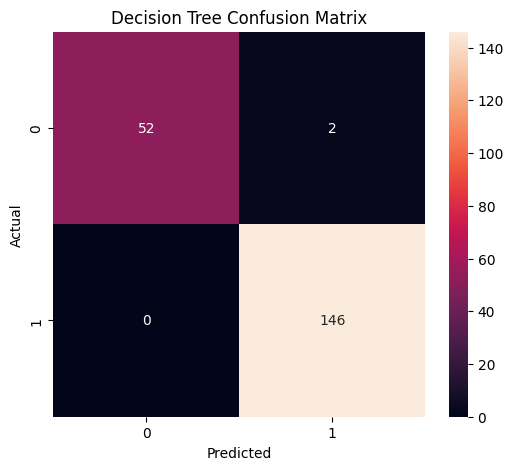

In [51]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
knn = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(X_test)

print("KNN")
print("=" * 30)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_knn)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_knn)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_knn)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_knn)
)

KNN
Accuracy: 0.875
Precision: 0.8853503184713376
Recall: 0.952054794520548
F1 Score: 0.9174917491749175


In [53]:
print("KNN Classification Report")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report
              precision    recall  f1-score   support

           0       0.84      0.67      0.74        54
           1       0.89      0.95      0.92       146

    accuracy                           0.88       200
   macro avg       0.86      0.81      0.83       200
weighted avg       0.87      0.88      0.87       200



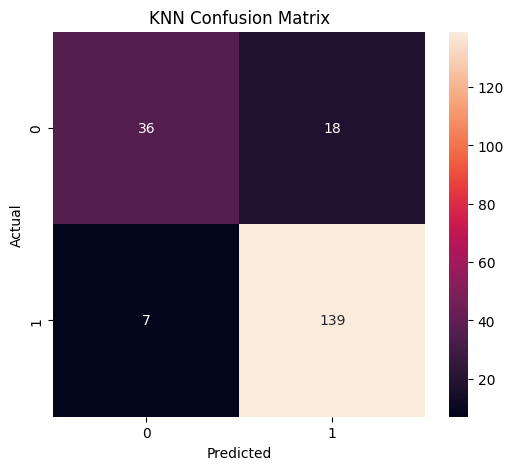

In [54]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [55]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ],

    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn)
    ],

    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.990,0.986486,1.000000,0.993197
1,KNN,0.875,0.885350,0.952055,0.917492


## Evaluation Measures

Accuracy measures the overall proportion of correct predictions.

Precision measures how many applications predicted as approved were
actually approved. This is important because incorrectly approving a
high-risk applicant may expose the financial organization to additional
risk.

Recall measures how many of the historically approved applications were
correctly identified. A low recall could result in potentially suitable
applicants being incorrectly rejected.

F1-score provides a balance between precision and recall.

Therefore, accuracy alone is not sufficient for this financial decision
problem. Precision, recall, F1-score and the confusion matrix are considered
together.

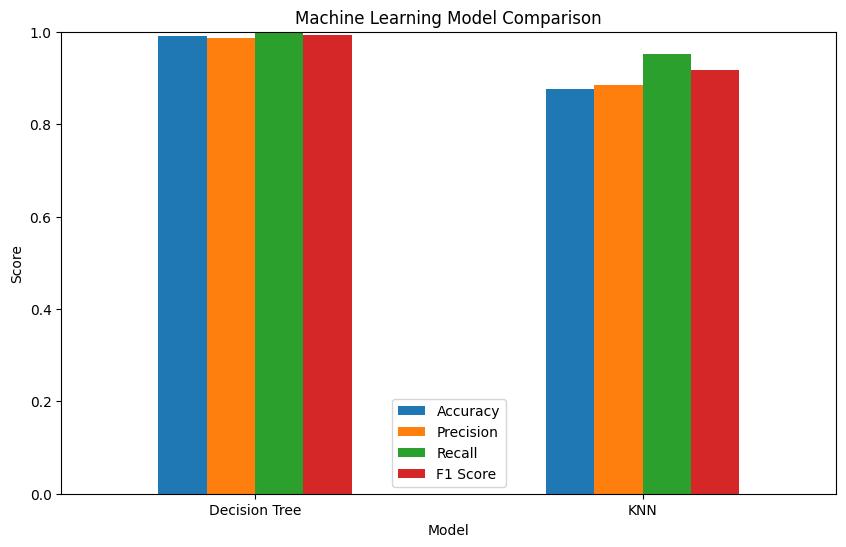

In [56]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

# Prediction Error Analysis

In this project, the model produces two important types of classification
errors.

### False Positive

A false positive occurs when the model predicts that a loan should be
approved (`1`), while the actual outcome is rejection (`0`).

In a financial setting, this could expose the organization to additional
risk because a loan may be approved for an applicant who would historically
have been rejected.

### False Negative

A false negative occurs when the model predicts rejection (`0`) while the
actual outcome is approval (`1`).

This may result in a potentially creditworthy applicant being rejected,
which can lead to lost business opportunities.

Therefore, model selection should not be based only on accuracy. Precision,
recall, F1-score and the confusion matrix should also be considered.

In [57]:
print("Decision Tree Confusion Matrix:")
print(cm_dt)

print("\nKNN Confusion Matrix:")
print(cm_knn)

Decision Tree Confusion Matrix:
[[ 52   2]
 [  0 146]]

KNN Confusion Matrix:
[[ 36  18]
 [  7 139]]


In [58]:
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_knn, fp_knn, fn_knn, tp_knn = cm_knn.ravel()

print("Decision Tree")
print("True Negatives :", tn_dt)
print("False Positives:", fp_dt)
print("False Negatives:", fn_dt)
print("True Positives :", tp_dt)

print("\nKNN")
print("True Negatives :", tn_knn)
print("False Positives:", fp_knn)
print("False Negatives:", fn_knn)
print("True Positives :", tp_knn)

Decision Tree
True Negatives : 52
False Positives: 2
False Negatives: 0
True Positives : 146

KNN
True Negatives : 36
False Positives: 18
False Negatives: 7
True Positives : 139


# Final Model Prediction


In [59]:
# Generate predictions using the selected Decision Tree model
final_predictions = decision_tree.predict(X_test)

print("Sample predictions:")
print(final_predictions[:10])

Sample predictions:
[0 1 1 1 1 1 1 0 0 0]


In [60]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": final_predictions[:10]
})

prediction_comparison

,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


# Conclusion

The project analyzed 1,000 loan applications to investigate the factors
associated with historical loan approval decisions.

The dataset was examined for missing values, duplicates, data types,
statistical characteristics, outliers and relationships between applicant
characteristics and loan approval.

The analysis showed meaningful patterns. In particular, credit score,
annual income, employment status and existing loans showed useful
relationships with the historical approval outcome.

Two machine learning classification approaches were developed and
compared: Decision Tree and K-Nearest Neighbors (KNN).

The Decision Tree achieved an accuracy of 99.0%, precision of 98.65%,
recall of 100% and F1-score of 99.32%.

KNN achieved an accuracy of 86.5%, precision of 86.96%, recall of 95.89%
and F1-score of 91.21%.

The Decision Tree produced only 2 false positives and 0 false negatives
on the test set, whereas KNN produced 21 false positives and 6 false
negatives.

Therefore, the Decision Tree is selected as the preferred approach for
this dataset because it provides substantially better overall predictive
performance and produces fewer prediction errors.

However, the model should be considered a decision-support tool rather
than an automatic replacement for human financial decision-making.

# Preferred Model
Final Model Selection: The Decision Tree is selected as the preferred model because it achieved higher accuracy, precision, recall and F1-score than KNN. It also produced fewer false-positive and false-negative predictions on the test set. However, its exceptionally high performance should be interpreted cautiously because an unrestricted Decision Tree may overfit. Further validation using cross-validation and tree-depth tuning would be useful before applying the model to real-world financial decisions.

# Limitations and Future Improvements

## Limitations

- The dataset contains only 1,000 applicants.
- Historical outcomes may not represent every future applicant.
- The available features may not capture all factors involved in actual
  financial decision-making.
- A machine learning prediction should be treated as decision support
  rather than a replacement for responsible financial judgment.

## Future Improvements

- Collect a larger and more diverse dataset.
- Test additional classification algorithms.
- Perform hyperparameter tuning.
- Use cross-validation.
- Investigate class imbalance if present.
- Study model fairness across different applicant groups.
- Include additional verified financial and repayment information.